### Importing all libraries:

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score

### Reading the data 

In [12]:
df = pd.read_csv('data.csv')
print("Data shape:", df.shape)
print(df.head())

Data shape: (2000, 6)
   Cancer stage  Clump thickness  No of week  Clump thickness_new  \
0           1.0        10.510076    6.166544            10.269649   
1           1.0        11.739776    7.024066            10.494287   
2           1.0         7.857070    5.909366             8.516879   
3           1.0        10.817929    5.920890             8.979736   
4           1.0        10.302407    6.984937             9.553005   

   No of week_new  True cancer stage  
0       11.999203                  1  
1        6.495638                  1  
2        7.102108                  1  
3        9.196251                  1  
4        7.120283                  1  


In [13]:
labeled_df = df[df['Cancer stage'].notna()].copy()  
unlabeled_X = df[['Clump thickness_new', 'No of week_new']].values  
y_true_new = df['True cancer stage'].values

### Ploting the data

### Creating a scatter plot for 200 datapoints

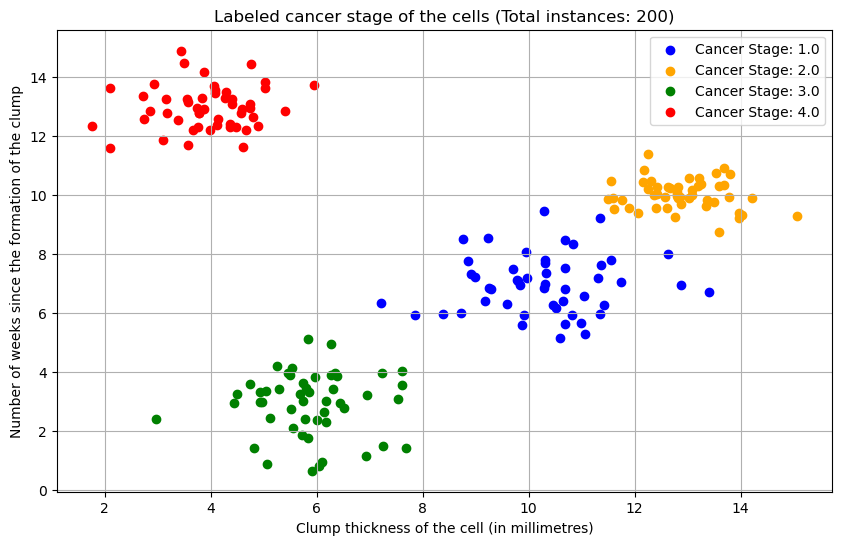

In [16]:
plt.figure(figsize=(10, 6))
plt.xlabel('Clump thickness of the cell (in millimetres)')
plt.ylabel('Number of weeks since the formation of the clump')
plt.title('Labeled cancer stage of the cells (Total instances: 200)')

colors = ['blue', 'orange', 'green', 'red']
markers = ['o', 'o', 'o', 'o']
labels = [f'Cancer Stage: {i+1}.0' for i in range(4)]

for i in range(4):
    stage_data = labeled_df[labeled_df['Cancer stage'] == i + 1]
    plt.scatter(stage_data['Clump thickness'], stage_data['No of week'],color=colors[i], marker=markers[i], label=labels[i])

plt.legend()
plt.grid(True)
plt.show()

### Overlaying the above scatter plot with new unlabeled 2000 datapoints:

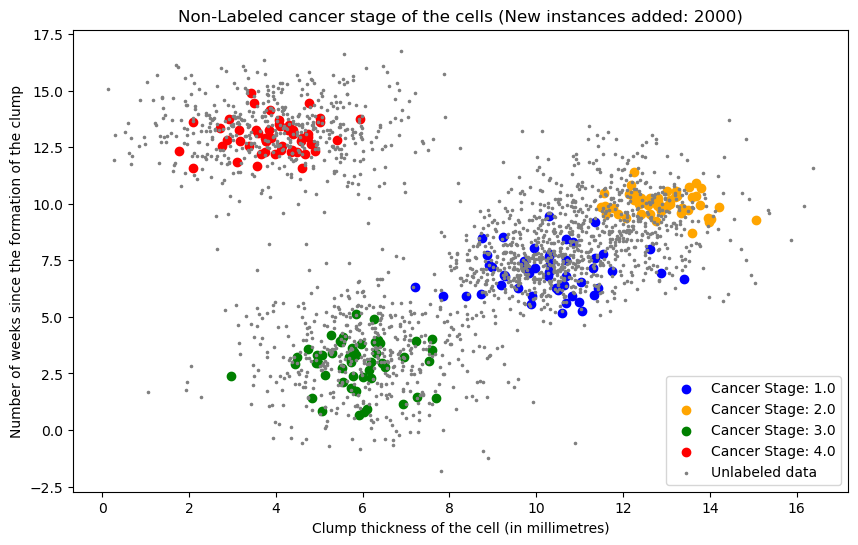

In [18]:
plt.figure(figsize=(10, 6))
plt.xlabel('Clump thickness of the cell (in millimetres)')
plt.ylabel('Number of weeks since the formation of the clump')
plt.title('Non-Labeled cancer stage of the cells (New instances added: 2000)')

colors = ['blue', 'orange', 'green', 'red']
markers = ['o', 'o', 'o', 'o']
labels = [f'Cancer Stage: {i+1}.0' for i in range(4)]

for i in range(4):
    stage_data = labeled_df[labeled_df['Cancer stage'] == i + 1]
    plt.scatter(stage_data['Clump thickness'], stage_data['No of week'],color=colors[i], marker=markers[i], label=labels[i])

plt.scatter(unlabeled_X[:, 0], unlabeled_X[:, 1],color='grey', marker='.', s=10, label='Unlabeled data')
plt.legend()
plt.show()

### Preparing labeled data and dropping rows with NaN values

/opt/anaconda3/lib/python3.12/site-packages/sklearn/semi_supervised/_self_training.py:244: UserWarning: y contains no unlabeled samples
  warnings.warn("y contains no unlabeled samples", UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SelfTrainingClassifier was fitted with feature names
  warnings.warn(


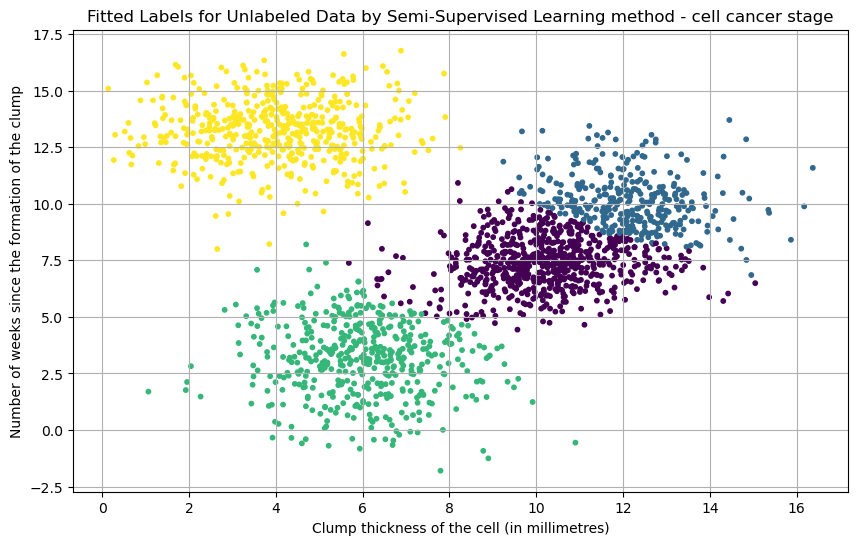

In [20]:
X_labeled = labeled_df[['Clump thickness', 'No of week']]
y_labeled = labeled_df['Cancer stage']


knn = KNeighborsClassifier(n_neighbors=5)
self_training_model = SelfTrainingClassifier(knn)


self_training_model.fit(X_labeled, y_labeled)
predicted_labels = self_training_model.predict(unlabeled_X)


plt.figure(figsize=(10, 6))
plt.scatter(unlabeled_X[:, 0], unlabeled_X[:, 1],
            c=predicted_labels, s=10, cmap='viridis')

plt.xlabel('Clump thickness of the cell (in millimetres)')
plt.ylabel('Number of weeks since the formation of the clump')
plt.title('Fitted Labels for Unlabeled Data by Semi-Supervised Learning method - cell cancer stage')
plt.grid(True)
plt.show()

 ### Compute and print accuracy score, plot classification report and the confusion matrix

Accuracy: 0.8905

Classification Report:
               precision    recall  f1-score   support

           1       0.71      0.98      0.82       500
           2       0.96      0.65      0.77       500
           3       1.00      0.94      0.97       500
           4       0.99      1.00      1.00       500

    accuracy                           0.89      2000
   macro avg       0.92      0.89      0.89      2000
weighted avg       0.92      0.89      0.89      2000


Confusion Matrix:
 [[488  12   0   0]
 [177 323   0   0]
 [ 26   0 471   3]
 [  1   0   0 499]]


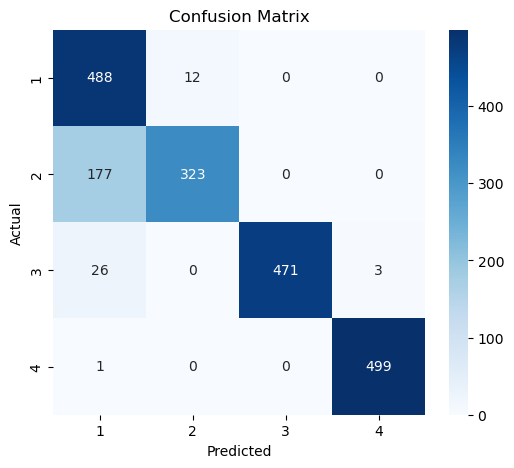

In [22]:
true_labels = df['True cancer stage']

acc = accuracy_score(true_labels, predicted_labels)
report = classification_report(true_labels, predicted_labels)
conf_mat = confusion_matrix(true_labels, predicted_labels)

print("Accuracy:", acc)
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_mat)


plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(true_labels), yticklabels=np.unique(true_labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Report:
1. Provide three applications of Semi-supervised learning.

Ans: Semi-supervised learning is used in speech recognition, image classification, and fraud detection, where only a small portion of data is labeled but large amounts of unlabeled data are available. It helps improve model performance without labeling all data.

2. What are the three assumptions of Semi-supervised learning?

Ans:There are three major assumptions, which are
Continuity(Smoothness) assumption:Data points which are similar to one another in the feature space are likely to share the same label.
Clustering assumption:The data is likely to be in groups or clusters and the points in the same cluster are likely to have the same output label.
Manifold assumption:
Small amount of data can be represented in a high dimensional space, though it can be concentrated in lower dimensional manifold of the space. The classifier can generalize more by acquiring this structure using unlabeled data because similar points on the manifold tend to share a common class.


3. What is significance each of using the above three assumptions in Semi-supervised Learning?

Ans:i) Smoothness Assumption:
It ensures that small changes in the input data do not cause large changes in the output, making the model’s predictions more stable and reliable.

ii) Cluster Assumption:
It helps the model place decision boundaries between clusters of data, which improves classification and reduces errors.

iii) Manifold Assumption:
It allows the algorithm to learn the underlying structure of the data in a lower-dimensional space, which helps in making more accurate predictions.

4. How does the Co-training method differ from the Self-training method of Semisupervised learning? Which one usually performs better for accuracy and such performance metrics?

Ans:
The self-training method uses one classifier that is trained on labeled data and then predicts pseudo-labels for unlabeled data. These confident predictions are added back to the training data to improve the model.
The co-training method uses two different classifiers trained on different feature sets. Each classifier labels new data for the other during training.
This interaction helps both models learn from each other.
In many cases, co-training performs better in terms of accuracy and reliability because the predictions are verified by two models.


5. How to evaluate the performance of a semi-supervised learning method while
training?

Ans:Performance is evaluated using validation data and metrics such as accuracy, precision, recall, and F1-score, while monitoring improvements as pseudo labelled data is added during iterations.Apart from these, we can also use the cross-validation on the labeled data to assess how well our model generalizes.
